# Data blocking

In this notebook I inspect the output of one strain-stress simulation with MACE potential, inspect the output, demonstrate data-blocking, and fix the analysis pipeline.

In [2]:
!which python

/home/gabrielecolombo/Thesis/PROJECT/.venv/bin/python


In [3]:
import numpy as np
import pandas as pd

from lammps_logfile import read_log

import matplotlib.pyplot as plt

from scipy.signal import periodogram, correlate

from ase.io import write

## Load data

Load and check everything is as expected.

In [5]:
thermo = read_log("log_new.lammps")
thermo = thermo[thermo['c_press_compute[1]'].notnull()]
# thermo = thermo[thermo['v_exx'].notnull()]
# thermo = thermo[thermo['v_eyy'].notnull()]


In [6]:
thermo.head()

,Step,Temp,PotEng,KinEng,TotEng,Press,c_press_compute[1],c_press_compute[2],c_press_compute[3],c_press_compute[4],c_press_compute[5],c_press_compute[6],run_num
0,0,308.48803,-711.03603,3.947646,-707.08838,-15098.723,-37960.416,-7342.4925,6.739796,163.47677,16.069478,56.796215,0
1,1,309.69395,-711.04471,3.963077,-707.08164,-15090.947,-37948.419,-7335.5156,11.094186,172.77616,17.857952,69.040945,0
2,2,309.90588,-711.05123,3.965789,-707.08544,-15083.087,-37939.064,-7324.0962,13.898452,177.53422,19.318019,76.318755,0
3,3,310.80759,-711.04765,3.977328,-707.07032,-15074.474,-37930.986,-7308.3687,15.932444,175.52456,19.699976,78.031469,0
4,4,310.49529,-711.01670,3.973332,-707.04337,-15063.588,-37923.240,-7285.7642,18.241294,168.72265,19.961669,73.064986,0


In [7]:
thermo.keys()

Index(['Step', 'Temp', 'PotEng', 'KinEng', 'TotEng', 'Press',
       'c_press_compute[1]', 'c_press_compute[2]', 'c_press_compute[3]',
       'c_press_compute[4]', 'c_press_compute[5]', 'c_press_compute[6]',
       'run_num'],
      dtype='object')

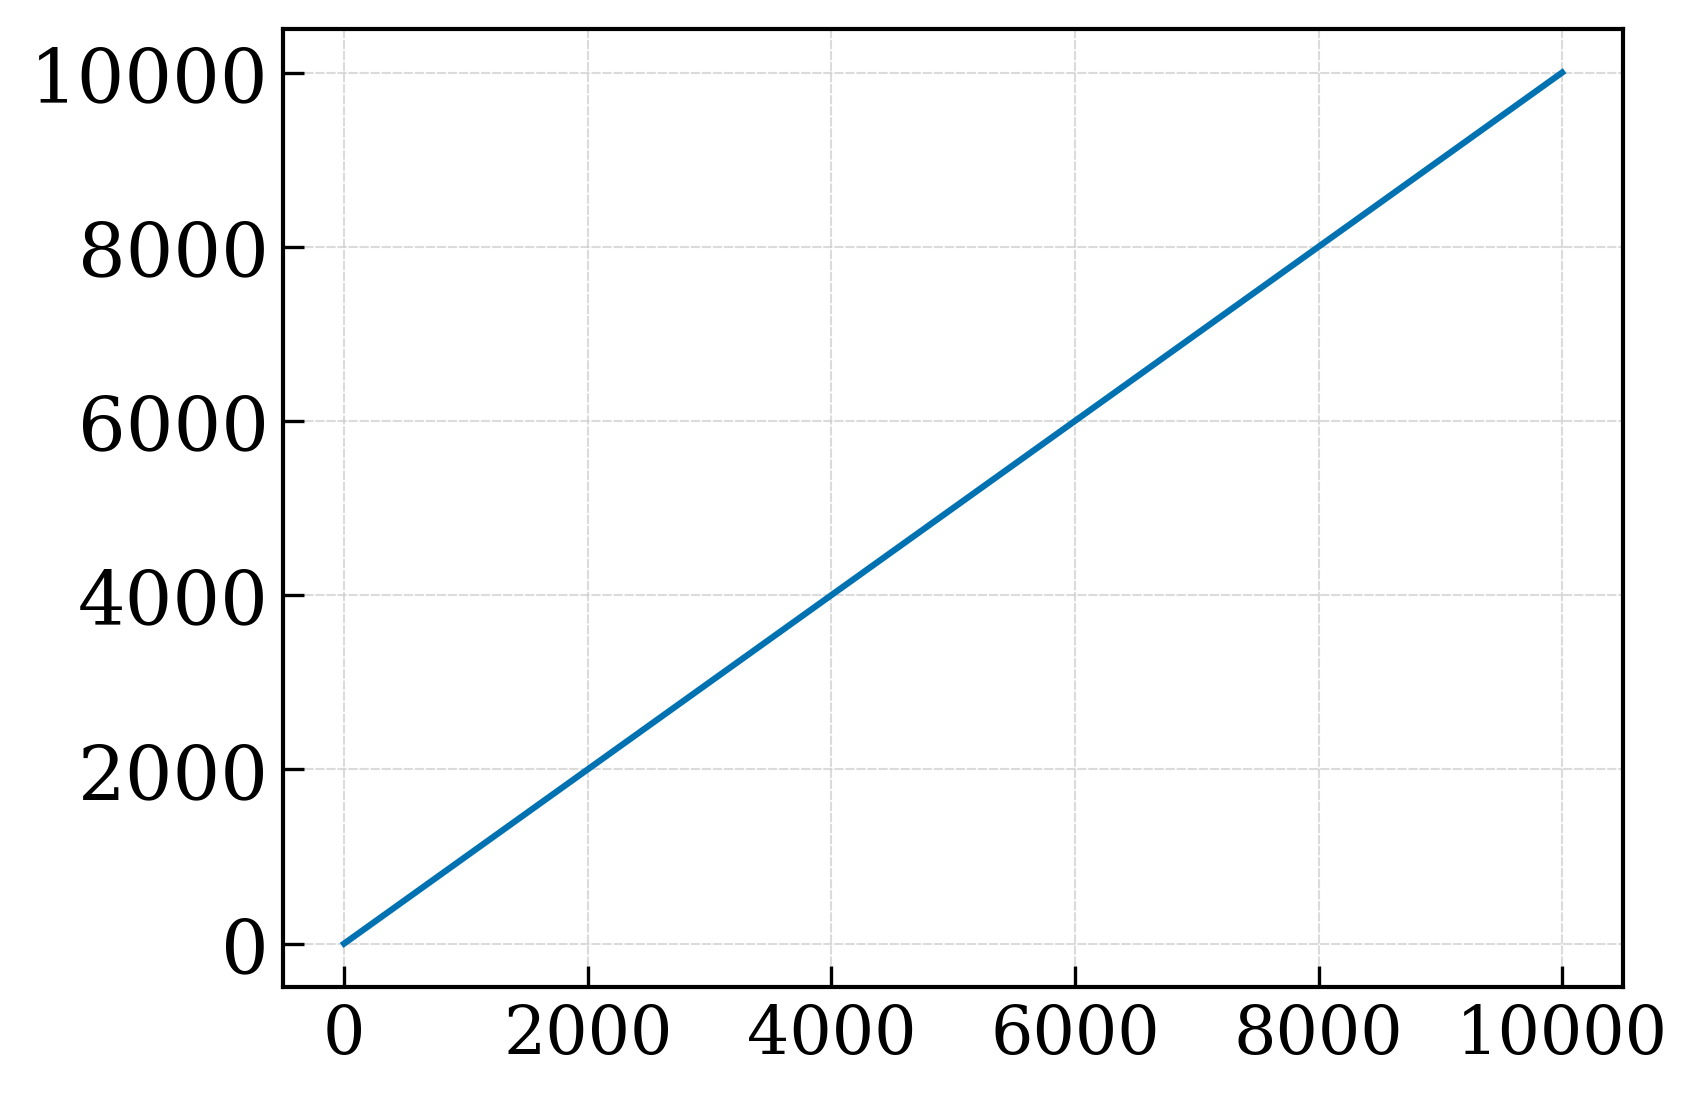

In [8]:
steps = thermo['Step']
plt.plot(steps)

## Raw strain-stress data

## Check Temperature

(0.0, 1000.0)

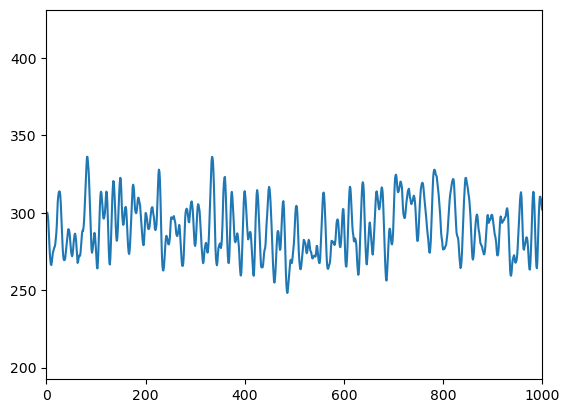

In [11]:
temps = thermo["Temp"]
plt.plot(temps)
plt.xlim(0,1e3)

## Check correlation time

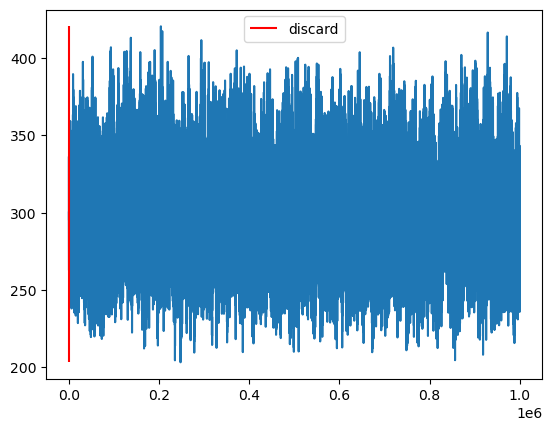

In [55]:
nsteps = 1000000 # number of steps at each strain
slice_idx = 0 # select the slice
timestep = 1e-3 # in pseconds seconds
discard = 0 # discard first steps that are correlated with previous equilibrium

data = thermo['Temp']

times = np.linspace(0, timestep*nsteps, num=nsteps)
data = data[slice_idx*nsteps:(slice_idx+1)*nsteps]
plt.plot(data)
plt.vlines(slice_idx*nsteps+discard, label = "discard", color = "red", ymin = np.min(data), ymax = np.max(data))

plt.legend()

data = data[discard:]
ndata = nsteps - discard
times = times[discard:]

Text(0.5, 0, 'frequency [THz]')

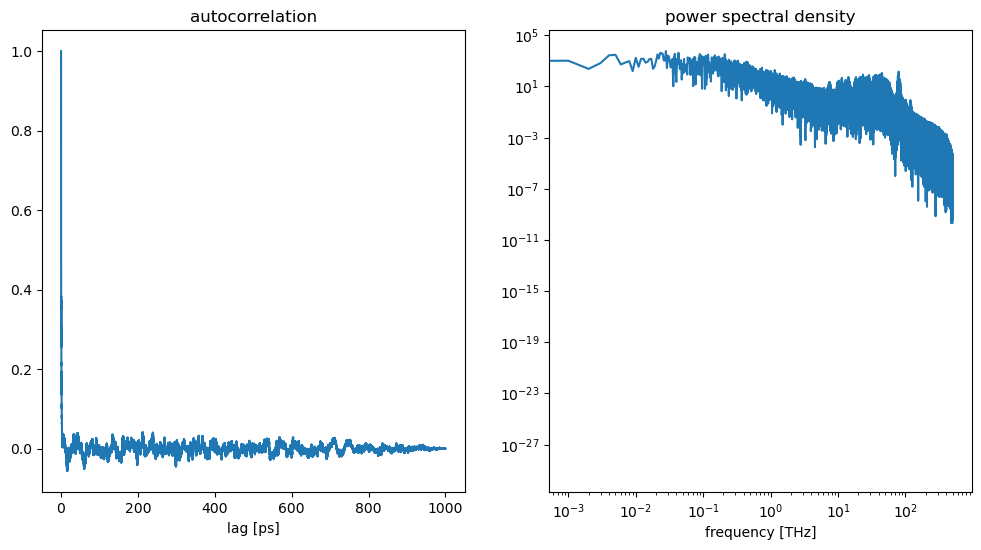

In [56]:
# remove the mean
unbiased_data = data - np.mean(data)
autocorrelation = correlate(unbiased_data, unbiased_data, "full")[ndata-1:]
autocorrelation /= autocorrelation[0]
sampling_freq = 1/timestep
fs, psd = periodogram(unbiased_data, sampling_freq, return_onesided=True)

fix, axs = plt.subplots(1,2, figsize = (12,6))

axs[0].set_title("autocorrelation")
axs[0].plot(times - times[0], autocorrelation)
axs[0].set_xlabel("lag [ps]")

axs[1].set_title("power spectral density")
axs[1].plot(fs, psd)
axs[1].set_yscale("log")
axs[1].set_xscale("log")
axs[1].set_xlabel("frequency [THz]")

10 299.30041969805 0.06941075316867992
100 299.30041969804995 0.17586837648706782
125 299.30041969805 0.1955879272059032
250 299.30041969805 0.27050421570672856
500 299.30041969805 0.368387178647759
1000 299.30041969805 0.4853591951402282
2500 299.30041969805 0.6323543737245302
5000 299.30041969805 0.708235610237422
10000 299.30041969805 0.7909300170909862
20000 299.30041969805 0.7394000703136361
50000 299.30041969805 0.6571414050478739


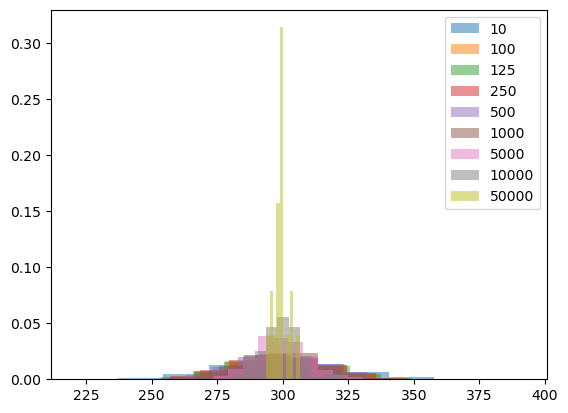

In [59]:
from data_blocking import *

block_sizes = [10,100,125,250,500,1000,2500, 5000, 10000, 20000, 50000]

mus = []
stds = []

for bs in block_sizes:
    means = compute_blocks(np.asarray(data), bs)
    mean, std = meanstd(means)
    print(bs, mean, std)
    if bs in [10,100,125,250,500,1000,1500,2000, 3000, 5000, 10000, 50000]:
        plt.hist(means, label=bs, alpha=0.5, density=True)

    mus.append(mean)
    stds.append(std)

plt.legend()

Text(0, 0.5, 'mean uncertainty')

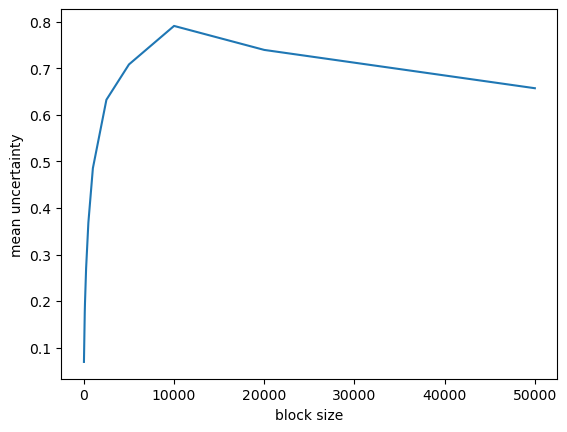

In [58]:
plt.plot(block_sizes, stds)
plt.xlabel("block size")
plt.ylabel("mean uncertainty")